In [1]:
!pip install -r requirements.txt --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


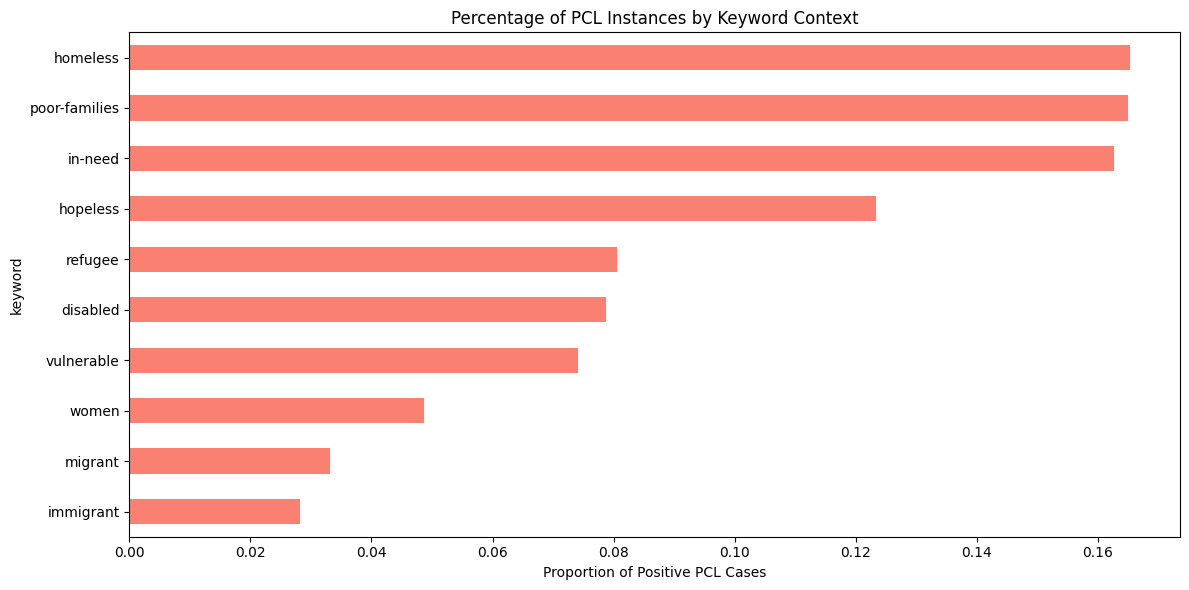

/tmp/ipykernel_3348/1633703678.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


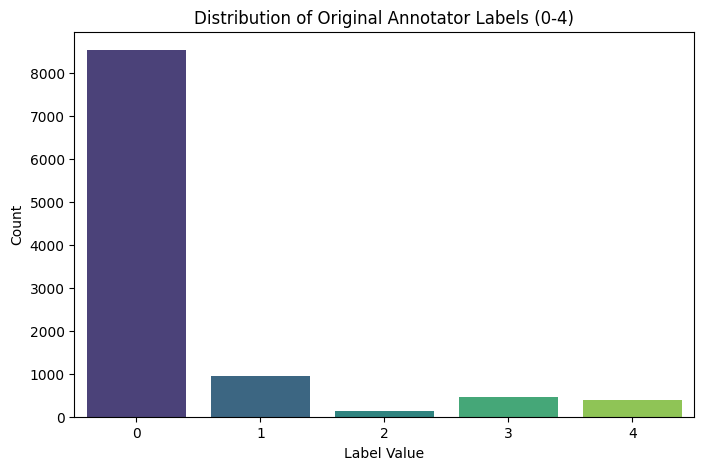

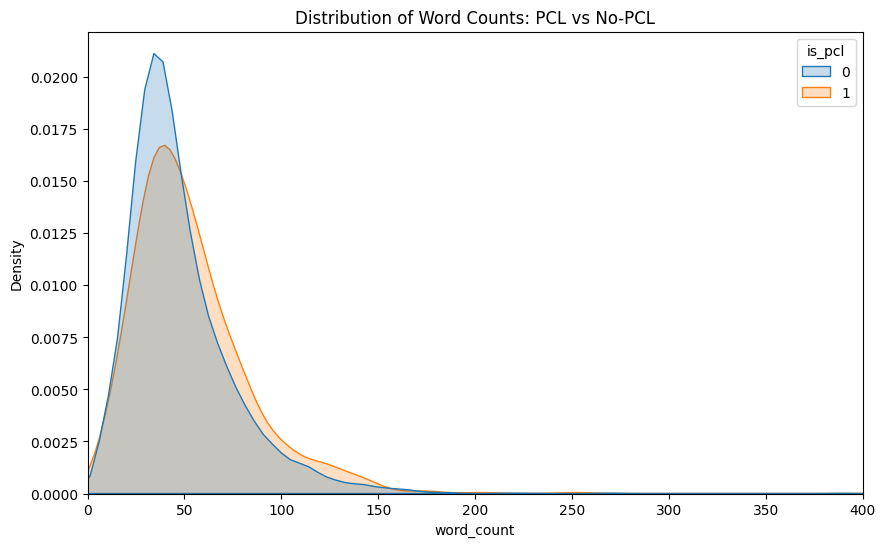

               Total  PCL_Positive      PCL_%
keyword                                      
homeless        1077           178  16.527391
poor-families    909           150  16.501650
in-need         1082           176  16.266174
hopeless        1005           124  12.338308
refugee         1068            86   8.052434
disabled        1028            81   7.879377
vulnerable      1080            80   7.407407
women           1070            52   4.859813
migrant         1088            36   3.308824
immigrant       1061            30   2.827521


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset
cols = ['id', 'article_id', 'keyword', 'country', 'text', 'label']
df = pd.read_csv('dontpatronizeme_pcl.tsv', sep='\t', names=cols, skiprows=4)

#Data Cleaning
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

#Define Binary Task 
df['is_pcl'] = df['label'].apply(lambda x: 1 if x >= 2 else 0)

#PCL Density per Keyword ---
plt.figure(figsize=(12, 6))
keyword_counts = df.groupby('keyword')['is_pcl'].value_counts(normalize=True).unstack()
keyword_counts[1].sort_values().plot(kind='barh', color='salmon')
plt.title('Percentage of PCL Instances by Keyword Context')
plt.xlabel('Proportion of Positive PCL Cases')
plt.tight_layout()
plt.show()

#Label Distribution (0-4) ---
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Original Annotator Labels (0-4)')
plt.xlabel('Label Value')
plt.ylabel('Count')
plt.show()

#Additional: Text Length Analysis ---
df['word_count'] = df['text'].str.split().str.len()
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='word_count', hue='is_pcl', common_norm=False, fill=True)
plt.title('Distribution of Word Counts: PCL vs No-PCL')
plt.xlim(0, 400) 
plt.show()

#Summary Statistics Table ---
summary = df.groupby('keyword').agg({
    'id': 'count',
    'is_pcl': 'sum'
}).rename(columns={'id': 'Total', 'is_pcl': 'PCL_Positive'})
summary['PCL_%'] = (summary['PCL_Positive'] / summary['Total']) * 100
print(summary.sort_values('PCL_%', ascending=False))

In [3]:
import os
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv()
token = os.getenv("HUGGING_FACE_TOKEN")

login(token=token)

In [4]:
import random
import transformers
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from datasets import Dataset
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from scipy.special import softmax
from transformers import RobertaForSequenceClassification, RobertaTokenizer, Trainer, TrainingArguments

def lock_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers.set_seed(seed)

lock_seeds(42)

In [5]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


raw_df = pd.read_csv('dontpatronizeme_pcl.tsv', sep='\t', skiprows=4, header=None)
raw_df = raw_df.iloc[:, [0, 4, 5]] 
raw_df.columns = ['id', 'text', 'orig_label']

train_ids = pd.read_csv('train_semeval_parids-labels.csv')
official_dev_ids = pd.read_csv('dev_semeval_parids-labels.csv')

raw_df['id'] = raw_df['id'].astype(str).str.strip()
train_ids['par_id'] = train_ids['par_id'].astype(str).str.strip()
official_dev_ids['par_id'] = official_dev_ids['par_id'].astype(str).str.strip()

train_df = pd.merge(train_ids[['par_id']], raw_df, left_on='par_id', right_on='id', how='inner')
official_dev_df = pd.merge(official_dev_ids[['par_id']], raw_df, left_on='par_id', right_on='id', how='inner')

train_df['orig_label'] = pd.to_numeric(train_df['orig_label'], errors='coerce')
train_df = train_df.dropna(subset=['orig_label', 'text'])
train_df['labels'] = (train_df['orig_label'] >= 2).astype(int)

official_dev_df['orig_label'] = pd.to_numeric(official_dev_df['orig_label'], errors='coerce')
official_dev_df = official_dev_df.dropna(subset=['orig_label', 'text'])
official_dev_df['labels'] = (official_dev_df['orig_label'] >= 2).astype(int)

internal_train_df, internal_dev_df = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['labels'], 
    random_state=42
)

print(f"Internal Train Size: {len(internal_train_df)} | PCL+: {internal_train_df['labels'].sum()}")
print(f"Internal Dev Size:   {len(internal_dev_df)} | PCL+: {internal_dev_df['labels'].sum()}")
print(f"Official Dev Size:   {len(official_dev_df)} | PCL+: {official_dev_df['labels'].sum()}")

model_name = "roberta-base" 
tokenizer = RobertaTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

internal_train_dataset = Dataset.from_pandas(internal_train_df).map(tokenize_function, batched=True)
internal_dev_dataset = Dataset.from_pandas(internal_dev_df).map(tokenize_function, batched=True)
official_dev_dataset = Dataset.from_pandas(official_dev_df).map(tokenize_function, batched=True)

internal_train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
internal_dev_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
official_dev_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

def model_init():
    return RobertaForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        weights = torch.tensor([1.0, 8.5], device=device, dtype=logits.dtype)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"f1": f1_score(labels, predictions, pos_label=1)}

training_args = TrainingArguments(
    output_dir="./BestModel",          
    eval_strategy="epoch",
    save_strategy="no",
    weight_decay=0.05,
    warmup_ratio=0.1,
    load_best_model_at_end=False,        
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(), 
    report_to="none",
    seed=42
)

trainer = WeightedTrainer(
    model_init=model_init,
    args=training_args,
    train_dataset=internal_train_dataset,
    eval_dataset=internal_dev_dataset,  
    compute_metrics=compute_metrics,
)

def my_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 3e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 2, 6),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
    }

print("\n--- Starting Hyperparameter Search ---")
best_run = trainer.hyperparameter_search(
    direction="maximize",
    hp_space=my_hp_space,
    n_trials=20
)

print(f"\nBest Hyperparameters Found: {best_run.hyperparameters}")

for n, v in best_run.hyperparameters.items():
    setattr(trainer.args, n, v)
trainer.args.save_strategy = "epoch"
trainer.args.eval_strategy = "epoch"
trainer.args.save_only_model = True
trainer.args.save_total_limit = 1
trainer.args.load_best_model_at_end = True

trainer.train()
tokenizer.save_pretrained("./BestModel")

print("\n--- Tuning Threshold on Internal Dev Set ---")
internal_dev_results = trainer.predict(internal_dev_dataset)
internal_probs = softmax(internal_dev_results.predictions, axis=1)[:, 1]

best_f1 = 0.0
best_threshold = 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    custom_preds = (internal_probs >= thresh).astype(int)
    current_f1 = f1_score(internal_dev_dataset['labels'], custom_preds, pos_label=1)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"Optimal Threshold Found: {best_threshold:.2f} (Internal Dev F1: {best_f1:.4f})")

print("\n--- Final Evaluation on Official Dev Set ---")
official_dev_results = trainer.predict(official_dev_dataset)
official_probs = softmax(official_dev_results.predictions, axis=1)[:, 1]

final_predictions = (official_probs >= best_threshold).astype(int)
final_f1 = f1_score(official_dev_dataset['labels'], final_predictions, pos_label=1)

print(f"Final Tuned F1 Score: {final_f1:.4f}")

with open("dev.txt", "w") as f:
    for pred in final_predictions:
        f.write(f"{pred}\n")
        
print("Process Complete.")



Using device: cuda
Internal Train Size: 6700 | PCL+: 635
Internal Dev Size:   1675 | PCL+: 159
Official Dev Size:   2093 | PCL+: 199


Map:   0%|          | 0/6700 [00:00<?, ? examples/s]

Map:   0%|          | 0/1675 [00:00<?, ? examples/s]

Map:   0%|          | 0/2093 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


--- Tuning Threshold on Internal Dev Set ---


Optimal Threshold Found: 0.70 (Internal Dev F1: 0.5687)

--- Final Evaluation on Official Dev Set ---


Final Tuned F1 Score: 0.5749
Process Complete.


In [6]:
import pandas as pd
from datasets import Dataset
from scipy.special import softmax

print("Loading Test Data...")
test_filename = 'task4_test.tsv' 

test_raw = pd.read_csv(test_filename, sep='\t', header=None)
test_df = test_raw[[4]].copy()
test_df.columns = ['text']
test_df['text'] = test_df['text'].fillna("")

print(f"Loaded {len(test_df)} rows. (Target: 3832)")

print("\nTokenising Test Data...")
test_dataset = Dataset.from_pandas(test_df).map(tokenize_function, batched=True)
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask'])

print("\nGenerating predictions...")
test_results = trainer.predict(test_dataset)

test_probs = softmax(test_results.predictions, axis=1)[:, 1]

final_test_predictions = (test_probs >= best_threshold).astype(int)

with open("test.txt", "w") as f:
    for pred in final_test_predictions:
        f.write(f"{pred}\n")
        
print("Saved predictions to test.txt")

Loading Test Data...
Loaded 3832 rows. (Target: 3832)

Tokenising Test Data...


Map:   0%|          | 0/3832 [00:00<?, ? examples/s]


Generating predictions...



--- 4. APPLYING THRESHOLD & SAVING ---
Saved predictions to test.txt


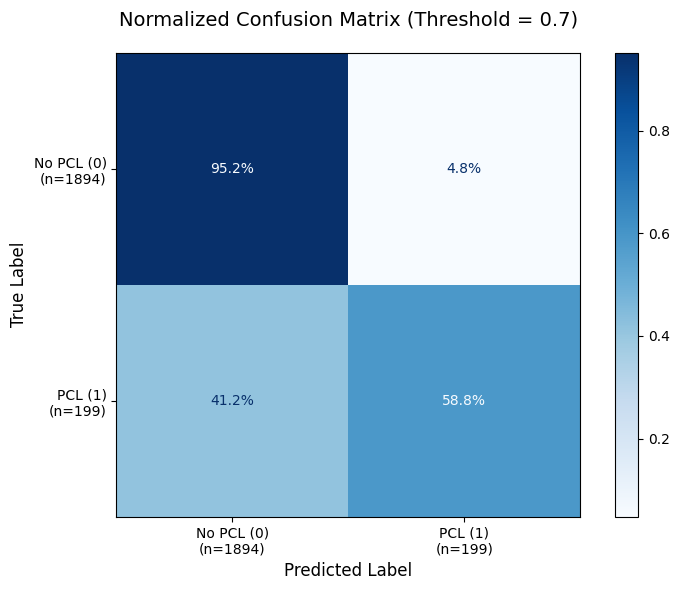

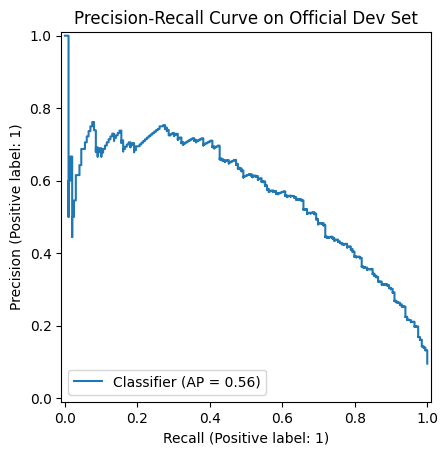

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

y_true = official_dev_dataset['labels']
y_pred = final_predictions

counts = np.bincount(y_true)
n_neg = counts[0]
n_pos = counts[1]

custom_labels = [f'No PCL (0)\n(n={n_neg})', f'PCL (1)\n(n={n_pos})']

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true, 
    y_pred, 
    display_labels=custom_labels, 
    normalize='true',          
    values_format='.1%',       
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title(f"Normalized Confusion Matrix (Threshold = {round(best_threshold,2)})", pad=20, fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.tight_layout()
plt.show()

PrecisionRecallDisplay.from_predictions(official_dev_dataset['labels'], official_probs)
plt.title("Precision-Recall Curve on Official Dev Set")
plt.show()

In [8]:
analysis_df = official_dev_df.copy()
analysis_df['predicted'] = final_predictions
analysis_df['probability'] = official_probs
false_positives = analysis_df[(analysis_df['predicted'] == 1) & (analysis_df['labels'] == 0)]

false_negatives = analysis_df[(analysis_df['predicted'] == 0) & (analysis_df['labels'] == 1)]

print(f"Total False Positives: {len(false_positives)}")
print(f"Total False Negatives: {len(false_negatives)}\n")

print("--- TOP 3 FALSE POSITIVES (Model thought it was PCL, but it wasn't) ---")
for text in false_positives.sort_values(by='probability', ascending=False)['text'].head(3):
    print(f"- {text}\n")

print("--- TOP 3 FALSE NEGATIVES (Model missed the PCL) ---")
for text in false_negatives.sort_values(by='probability', ascending=True)['text'].head(3):
    print(f"- {text}\n")

Total False Positives: 91
Total False Negatives: 82

--- TOP 3 FALSE POSITIVES (Model thought it was PCL, but it wasn't) ---
- But more than taking personal strength from the heroines of Philippine culture , Alma finds greater inspiration in being able to share her skills to build on the dreams of women and children , " I look at art not as a career but as a spiritual expression . Art should bring out what is innately beautiful , especially to those who are hopeless . "

- Christmas is celebration of the birth of not merely a child , but a child who changed the destiny of humans forever . It is celebration of the fact that God wanted to be a part of the human race and so he took on flesh and blood and became human like us . We can also show unconditional love through our good deeds and helping those who are in need of our help and care . Be human and merciful .

- I mention these moments to highlight and illustrate the potential that young people have to change our society . In all the